# PART 1 — Introduction to Word Embeddings

## Task 1: Understanding Word Embeddings (Conceptual)

**1. What are word embeddings?**

Word embeddings are dense, low-dimensional vector representations of words in a continuous vector space. Each word is mapped to a fixed-length vector (e.g., 100 or 300 dimensions) where the position and distance between vectors capture semantic and syntactic relationships. Words with similar meanings (e.g., "king" and "queen") are placed closer together in this space.

**2. Why do one-hot encoding and Bag of Words (BoW) fail to capture semantics?**

- **One-hot encoding** represents each word as a sparse vector with a single '1' and the rest '0's. The vector size equals the vocabulary size, leading to very high dimensionality and the "curse of dimensionality." It treats all words as completely independent with no notion of similarity or meaning.
- **Bag of Words (BoW)** counts word frequencies but ignores word order, context, and relationships between words. It also suffers from high dimensionality and sparsity.

Both methods fail to capture **semantic relationships** — for example, they cannot understand that "happy" and "joyful" are similar.

**3. How do word embeddings solve these problems?**

Word embeddings solve these issues by:
- Representing words as **dense vectors** with much lower dimensions.
- Learning representations from the context in which words appear, so semantically similar words get similar vectors.
- Capturing meaningful relationships (e.g., king – man + woman ≈ queen) through vector arithmetic.
- Enabling better performance in downstream NLP tasks like sentiment analysis, machine translation, and text classification.

---

# PART 2 — Word2Vec Overview & Techniques

## Task 2: Word2Vec Overview

**1. Explain what Word2Vec is.**

Word2Vec is a popular unsupervised algorithm developed by Google (Mikolov et al., 2013) that learns high-quality word embeddings from a large text corpus. It uses shallow neural networks to create vector representations where words appearing in similar contexts have similar vectors.

**2. Explain the idea of predicting words from context.**

The core idea behind Word2Vec is based on the **distributional hypothesis**: "A word is characterized by the company it keeps." The model learns word meanings by looking at the surrounding words (context). It trains by either predicting a target word from its context or predicting context words from a target word. This allows the model to understand semantic relationships automatically.

**3. Define:**

- **Vocabulary**: The set of all unique words present in the training corpus. Word2Vec creates an embedding vector for each word in the vocabulary.
- **Context window**: The number of words before and after the target word that are considered as context. For example, a context window of size 2 means the model looks at 2 words on each side of the target word.
- **Embedding dimension**: The size (length) of the vector representation for each word (commonly 100, 200, or 300 dimensions). Higher dimensions can capture more nuanced relationships but require more computation.

## Task 3: Types of Word2Vec Techniques

**1. CBOW (Continuous Bag of Words)**

- CBOW predicts the **target word** (center word) using the surrounding context words.
- It takes the average of the context word vectors and tries to predict the middle word.
- **Advantages**: Faster to train and performs well on frequent words. Good for large datasets.
- **Example**: Context = ["the", "cat", "on", "the"] → Predict "mat"

**2. Skip-Gram**

- Skip-Gram predicts the **context words** given the target (center) word.
- It uses the target word to predict multiple surrounding words.
- **Advantages**: Better at capturing relationships for **rare words** and works well with smaller datasets. Provides more detailed semantic information.
- **Example**: Target = "mat" → Predict ["the", "cat", "on", "the"]

**When to use each:**

- Use **CBOW** when you have a large corpus, want faster training, and are more concerned with frequent words.
- Use **Skip-Gram** when working with smaller datasets or when rare words and precise semantic relationships are important.

---

# PART 3 — Training Word2Vec on Custom Data

## Task 4: Neural Network Intuition Behind Word2Vec

**1. Input layer representation**

In Word2Vec (especially CBOW), the input layer receives the **context words** surrounding the target word. Each context word is represented as a **one-hot encoded vector**.  
If the vocabulary size is V, then each input word becomes a sparse vector of length V with a single '1' at the position of that word and '0's elsewhere. For multiple context words, their one-hot vectors are fed into the network (and usually averaged in CBOW).

**2. Hidden layer (embedding layer)**

The hidden layer is a fully connected layer with **no activation function** (linear). Its weight matrix (size V × N, where N is the embedding dimension) acts as the **lookup table** for word embeddings.  
When a one-hot vector is multiplied by this weight matrix, it simply selects the corresponding row — which becomes the dense embedding vector for that word. In CBOW, the embeddings of all context words are averaged to form a single hidden representation.

**3. Output layer**

The output layer is a softmax layer with V neurons (one for each word in the vocabulary). It predicts the probability distribution over all words in the vocabulary for the target word.  
The goal during training is to make the probability of the actual target word as high as possible.

**4. How weights become word embeddings**

After training, the weights of the **hidden layer** (the V × N matrix) become the final **word embeddings**. Each row in this matrix corresponds to one word in the vocabulary, and the values in that row form its dense vector representation. These learned vectors capture semantic relationships because the model was trained to predict words based on context.

**Simple Diagram (Text-based)**

Input Layer (One-hot vectors of context words)
↓
Hidden Layer (Embedding Layer - Weight Matrix V x N)
(Averaging in CBOW)
↓
Output Layer (Softmax → Probability of target word)
The embeddings are extracted from the **hidden layer weights** after the model converges.

---


In [ ]:
import pandas as pd
import numpy as np
import re
from nltk.tokenize import sent_tokenize, word_tokenize
import nltk
from nltk.stem import WordNetLemmatizer
df = pd.read_csv(r'D:\aiLearning\tuteDude_learning\assignment17\harry_potter_reviews.csv')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def nlp_preprocess(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Lowercasing + Noise removal (from Task 3)
    text = text.lower()
    text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = ' '.join(text.split())
    
    # 2. Stopword removal
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    
    # 3. Lemmatization (preferred over stemming)
    lemmatized = [lemmatizer.lemmatize(word) for word in words]
    
    return ' '.join(lemmatized)

# Apply final pipeline
df['final_clean_text'] = df['comment'].apply(nlp_preprocess)

## Task 5: Prepare Text for Word2Vec

In [ ]:


# nltk.download('punkt')   # Run once if needed

# Assuming df['final_clean_text'] or df['clean_text_advanced'] exists from previous tasks
# Using 'final_clean_text' as it is the most processed

sentences = []

for text in df['final_clean_text'].dropna():
    # 1. Tokenize cleaned text into sentences
    sent_list = sent_tokenize(text)
    
    for sent in sent_list:
        # 2. Tokenize sentences into words
        word_list = word_tokenize(sent)
        if len(word_list) > 0:   # avoid empty lists
            sentences.append(word_list)

# 3. sentences is now a list of lists
print("Total number of sentences prepared:", len(sentences))
print("\nFirst 10 samples:")
for i in range(10):
    print(sentences[i])

Total number of sentences prepared: 491

First 10 samples:
['transition', 'scene', 'awkward', 'soundtrack', 'forgettable']
['severus', 'snapes', 'role', 'add', 'intriguing', 'layer']
['pacing', 'bit', 'slow', 'character', 'charming']
['hagrids', 'love', 'magical', 'creature', 'heartwarming']
['neville', 'longbottoms', 'courage', 'aweinspiring']
['rubeus', 'hagrids', 'love', 'magical', 'creature', 'endearing']
['severus', 'snapes', 'complexity', 'add', 'depth', 'story']
['albus', 'dumbledores', 'presence', 'feel', 'unnecessary', 'distracting']
['ron', 'weasleys', 'humor', 'add', 'delightful', 'touch']
['hermione', 'granger', 'determination', 'inspiring']


In [ ]:
from gensim.models import Word2Vec

# Train Word2Vec model with specified parameters (CBOW)
model = Word2Vec(
    sentences=sentences,
    vector_size=100,      # embedding dimension
    window=5,             # context window size
    min_count=1,          # ignore words with frequency < 1
    sg=0,                 # 0 = CBOW, 1 = Skip-Gram
    workers=4,            # number of CPU cores (faster training)
    seed=42               # for reproducibility
)

# Print required information
print("Vocabulary Size:", len(model.wv))
print("\nEmbedding vector shape for a sample word:")

# Pick any word that exists in vocabulary (change if needed)
sample_word = list(model.wv.index_to_key)[0]   # first word in vocab
print(f"Sample word: '{sample_word}'")
print(model.wv[sample_word][:10])  # print first 10 dimensions
print("\nFull vector shape:", model.wv[sample_word].shape)

Vocabulary Size: 522

Embedding vector shape for a sample word:
Sample word: 'character'
[-0.00722495  0.00642525  0.00184101 -0.0005869  -0.00285685  0.00980612
 -0.00696567  0.00615324 -0.00967848 -0.00789811]

Full vector shape: (100,)


In [ ]:
from gensim.models import Word2Vec

# Train Word2Vec model with specified parameters (CBOW)
model = Word2Vec(
    sentences=sentences,
    vector_size=100,      # embedding dimension
    window=5,             # context window size
    min_count=1,          # ignore words with frequency < 1
    sg=1,                 # 0 = CBOW, 1 = Skip-Gram
    workers=4,            # number of CPU cores (faster training)
    seed=42               # for reproducibility
)

# Print required information
print("Vocabulary Size:", len(model.wv))
print("\nEmbedding vector shape for a sample word:")

# Pick any word that exists in vocabulary (change if needed)
sample_word = list(model.wv.index_to_key)[0]   # first word in vocab
print(f"Sample word: '{sample_word}'")
print(model.wv[sample_word][:10])  # print first 10 dimensions
print("\nFull vector shape:", model.wv[sample_word].shape)

Vocabulary Size: 522

Embedding vector shape for a sample word:
Sample word: 'character'
[-0.00283247  0.01310783 -0.00058255  0.00350723 -0.0078554   0.01694242
  0.00054165  0.01106519 -0.01755667 -0.00750435]

Full vector shape: (100,)


In [ ]:
word = "good"          # Change this word as per your dataset

if word in model.wv:
    similar_words = model.wv.most_similar(word, topn=5)
    print(f"Words most similar to '{word}':\n")
    for w, score in similar_words:
        print(f"{w:15} → Similarity: {score:.4f}")
else:
    print(f"Word '{word}' not found in vocabulary.")

Words most similar to 'good':

believe         → Similarity: 0.3078
revealed        → Similarity: 0.3007
taking          → Similarity: 0.2996
wondrous        → Similarity: 0.2483
capturing       → Similarity: 0.2441


In [ ]:
# Classic Word2Vec vector arithmetic
try:
    result = model.wv.most_similar(positive=['neville', 'dumbledore'], negative=['good'], topn=5)
    
    print("Vector Arithmetic: king - man + woman\n")
    print("Top 5 closest words:")
    for word, similarity in result:
        print(f"{word:15} → {similarity:.4f}")
        
except KeyError as e:
    print(f"Error: {e} — One of the words is not in the vocabulary.")

Vector Arithmetic: king - man + woman

Top 5 closest words:
like            → 0.4450
character       → 0.3844
cunning         → 0.3755
magical         → 0.3630
aura            → 0.3532


In [ ]:
# Test semantic relationships relevant to your dataset
# Example: Replace with words that appear in your text data

test_pairs = [
    ("movie", "film"),
    ("good", "nice"),
    ("like", "love"),
    ("good", "forgettable")
]

print("Testing Semantic Relationships:\n")
for w1, w2 in test_pairs:
    if w1 in model.wv and w2 in model.wv:
        similarity = model.wv.similarity(w1, w2)
        print(f"Similarity between '{w1}' and '{w2}': {similarity:.4f}")
    else:
        print(f"One of the words '{w1}' or '{w2}' not in vocabulary.")

Testing Semantic Relationships:

Similarity between 'movie' and 'film': 0.3599
Similarity between 'good' and 'nice': 0.0675
Similarity between 'like' and 'love': 0.1918
Similarity between 'good' and 'forgettable': 0.0248


In [ ]:
# Additional useful operations

print("=== Additional Word2Vec Operations ===\n")

# 1. Find similar words to another sample word
sample = "love"   # Change according to your data
if sample in model.wv:
    print(f"Top 8 words similar to '{sample}':")
    for word, sim in model.wv.most_similar(sample, topn=8):
        print(f"  {word:15} {sim:.4f}")

# 2. Get the embedding vector of a word
word_vec = model.wv["good"]
print(f"\nShape of embedding vector for 'good': {word_vec.shape}")

# 3. Check if a word exists in vocabulary
print(f"\nVocabulary size: {len(model.wv)}")
print(f"Does 'awesome' exist? {'awesome' in model.wv}")

=== Additional Word2Vec Operations ===

Top 8 words similar to 'love':
  depth           0.4759
  montage         0.4512
  character       0.4474
  hagrids         0.4304
  magical         0.3985
  stunning        0.3903
  film            0.3866
  unengaging      0.3820

Shape of embedding vector for 'good': (100,)

Vocabulary size: 522
Does 'awesome' exist? False


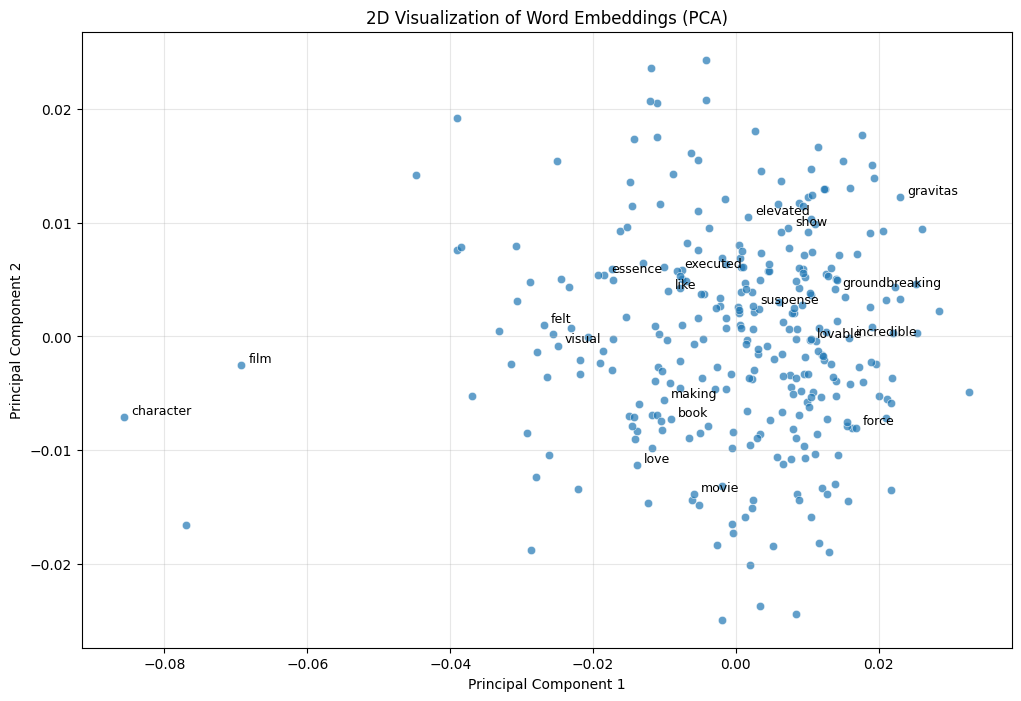

: 

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Get all word vectors and corresponding words
words = list(model.wv.index_to_key)[:300]  # Take top 300 most frequent words for clear plot
word_vectors = np.array([model.wv[word] for word in words])

# 1. Reduce dimensions using PCA (to 2D)
pca = PCA(n_components=2, random_state=42)
reduced_vectors = pca.fit_transform(word_vectors)

# 2. Plot in 2D
plt.figure(figsize=(12, 8))
sns.scatterplot(x=reduced_vectors[:, 0], y=reduced_vectors[:, 1], alpha=0.7)

# Annotate some interesting words
for i, word in enumerate(words):
    if i % 20 == 0 or word in ['good', 'bad', 'movie', 'film', 'like', 'love']:  # Adjust based on your data
        plt.annotate(word, xy=(reduced_vectors[i, 0], reduced_vectors[i, 1]),
                     xytext=(5, 2), textcoords='offset points', fontsize=9)

plt.title("2D Visualization of Word Embeddings (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, alpha=0.3)
plt.show()

Task 10: Observations & Limitations
1. Difference between CBOW & Skip-Gram in practice

CBOW (Continuous Bag of Words) predicts the target (center) word from its surrounding context words. It is faster to train and performs better with frequent words. It smooths the context by averaging and works well on large datasets.
Skip-Gram does the opposite — it predicts the surrounding context words from the target word. It is slower but better at capturing relationships for rare words and provides more detailed semantic information.
In practice: Use CBOW when training speed and frequent words matter. Use Skip-Gram when your corpus is smaller or you care more about rare terms and precise analogies.

2. Advantages of Word2Vec over TF-IDF

Word2Vec produces dense, low-dimensional vectors (e.g., 100–300 dimensions) that capture semantic meaning and relationships between words.
It understands context and similarity (e.g., "king – man + woman ≈ queen"), while TF-IDF only counts word importance and treats words as independent.
Word2Vec embeddings generalize better across unseen data and support vector arithmetic, making them more powerful for tasks like sentiment analysis, clustering, and analogy detection.
TF-IDF creates sparse, high-dimensional vectors and fails to capture meaning or synonyms.

3. Limitations of Word2Vec

Static embeddings: Each word gets only one fixed vector regardless of context (e.g., "bank" has the same vector whether it means riverbank or financial bank — polysemy problem).
Out-of-vocabulary (OOV) words: Cannot generate embeddings for words not seen during training.
Does not handle sub-word information or morphology well.
Cannot capture long-range dependencies or word order effectively beyond the context window.
May inherit biases present in the training corpus.

4. Why context still matters in modern NLP (lead-in to transformers)

Early models like Word2Vec assign a single static vector to each word, ignoring how meaning changes with surrounding text. However, human language is highly contextual — the same word can have completely different meanings depending on the sentence.
Modern NLP (especially Transformers like BERT and GPT) addresses this by generating contextualized embeddings. Each occurrence of a word gets a different vector based on the full sentence or document. The self-attention mechanism allows every word to "attend" to all other words simultaneously, capturing both short and long-range dependencies efficiently.
This contextual understanding is why transformers have dramatically improved performance in tasks like machine translation, question answering, and sentiment analysis.